# MNIST Dataset Preparation

This cell loads MNIST with standard normalization and builds DataLoader objects for training and test splits.

In [1]:
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

MNIST_ROOT = './data'
BATCH_SIZE = 64
RANDOM_SEED = 42

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # recommended MNIST mean/std
])

train_dataset = datasets.MNIST(root=MNIST_ROOT, train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root=MNIST_ROOT, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Loaded MNIST: train={len(train_dataset)} test={len(test_dataset)}")

Loaded MNIST: train=60000 test=10000


# Exploratory Data Analysis

Plot a small sample of MNIST digits to verify the loader output.

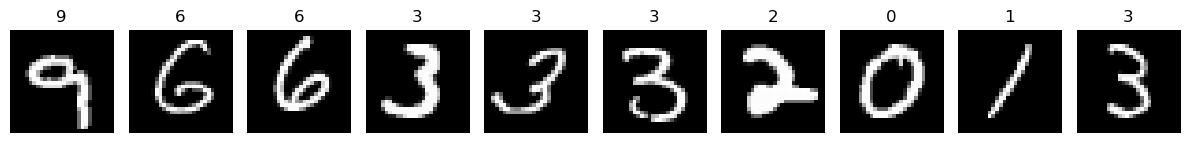

In [2]:
import matplotlib.pyplot as plt


def visualize_samples(data_loader, n=10):
    batch = next(iter(data_loader))
    images, labels = batch
    fig, axes = plt.subplots(1, n, figsize=(12, 2))
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(str(labels[i].item()))
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_samples(train_loader, n=10)

# Preprocess sklearn digits dataset

Using a built-in dataset for quick tabular exploration and baseline model checks.

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random_state = 42

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("train", X_train_scaled.shape, y_train.shape)
print("test", X_test_scaled.shape, y_test.shape)

train (1437, 64) (1437,)
test (360, 64) (360,)


# Visualize feature relationships

Use an informative subset of pixels for pairwise scatter; full 64-feature pairplot is expensive, so we sample.

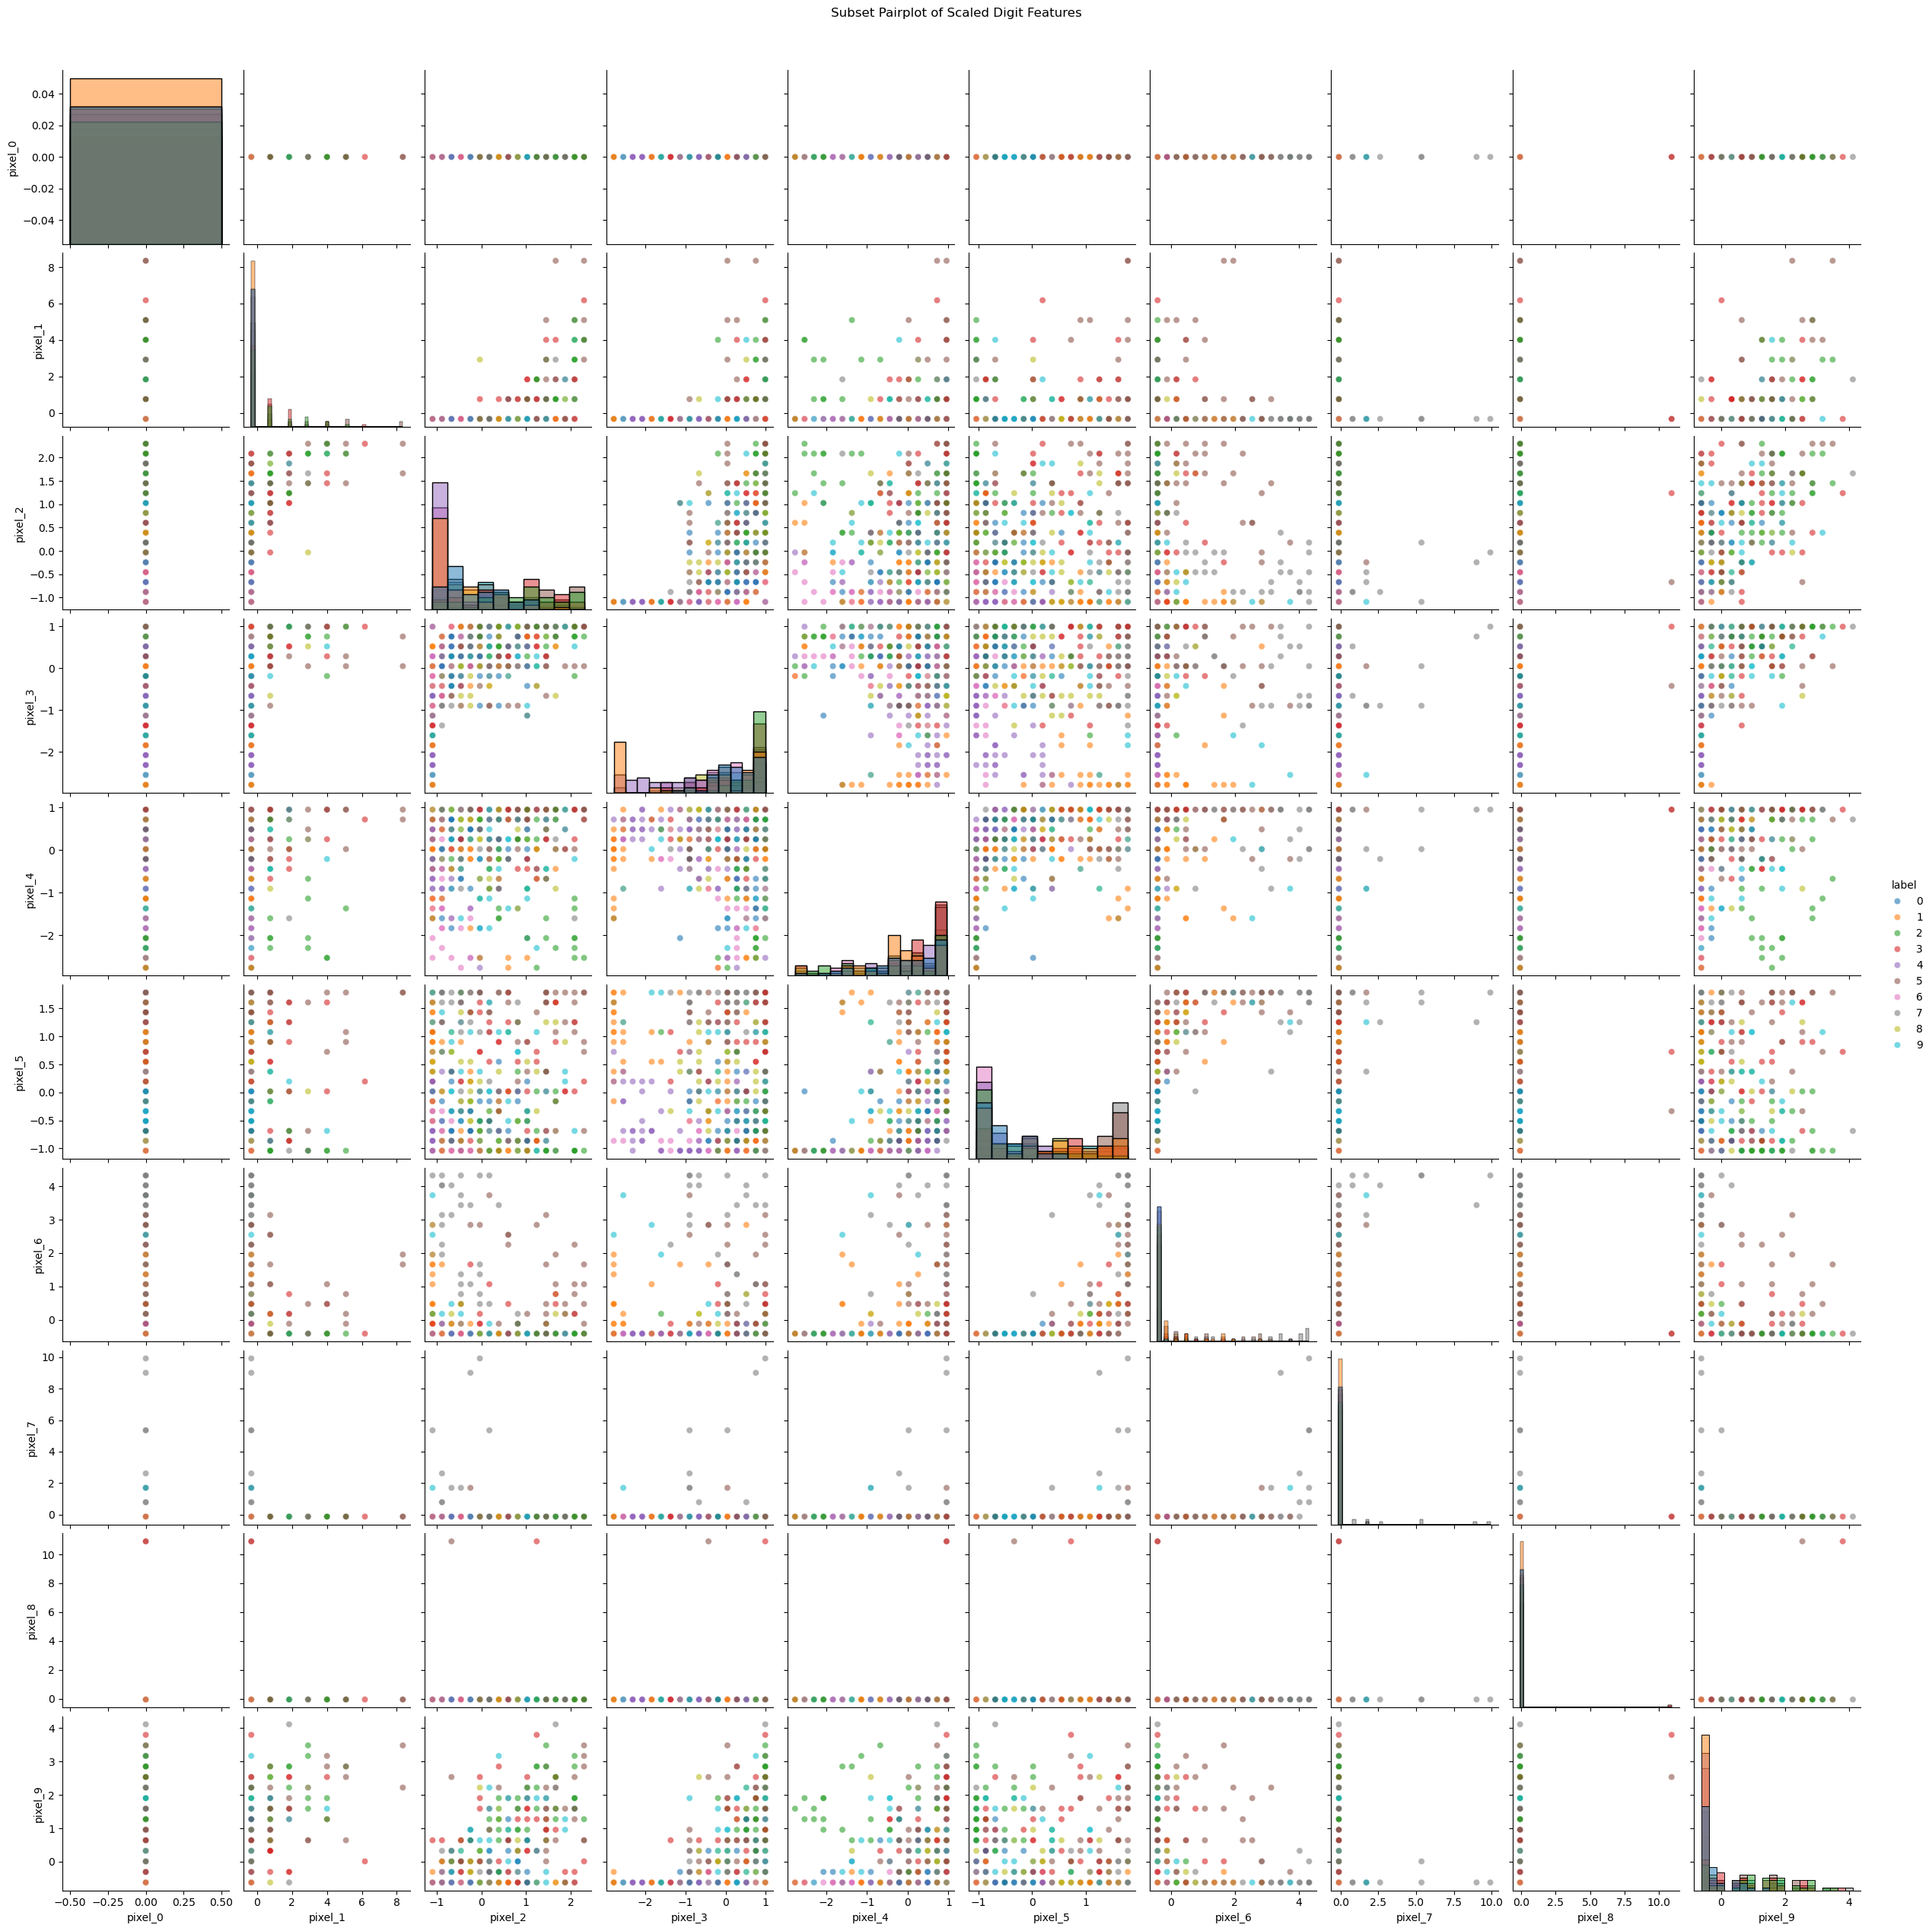

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pixel_cols = [f'pixel_{i}' for i in range(X_train_scaled.shape[1])]
df = pd.DataFrame(X_train_scaled, columns=pixel_cols)
df['label'] = y_train

selected_cols = pixel_cols[:10]

sns.pairplot(df.loc[:500, selected_cols + ['label']], hue='label', palette='tab10', diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle("Subset Pairplot of Scaled Digit Features", y=1.02)
plt.show()

# Data hygiene checks

Handle missing and infinite values, and summarize statistics.

In [5]:
df = df.copy()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(axis=0, inplace=True)

df_summary = df.describe()
print(df_summary.loc[['mean', 'std', 'min', 'max']])
print('\nData shape after cleanup:', df.shape)

      pixel_0       pixel_1       pixel_2       pixel_3       pixel_4  \
mean      0.0 -4.326548e-17  2.472313e-17  2.002573e-16  1.780065e-16   
std       0.0  1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00   
min       0.0 -3.304622e-01 -1.095159e+00 -2.788100e+00 -2.765649e+00   
max       0.0  8.343040e+00  2.298357e+00  9.889442e-01  9.527184e-01   

           pixel_5       pixel_6       pixel_7       pixel_8       pixel_9  \
mean  1.977850e-17 -1.730619e-17 -3.708469e-17  2.472313e-18 -1.421580e-17   
std   1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00   
min  -1.040373e+00 -4.108676e-01 -1.258432e-01 -6.103492e-02 -6.226093e-01   
max   1.783075e+00  4.319561e+00  1.357390e+01  2.186576e+01  4.117886e+00   

      ...      pixel_55      pixel_56      pixel_57      pixel_58  \
mean  ... -2.966776e-17  7.416939e-18  1.236156e-18  8.900327e-17   
std   ...  1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00   
min   ... -2.007704e-01 -2.638899e-0

# Baseline model: logistic regression

Train and evaluate on the scaled digit dataset.

=== Baseline Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



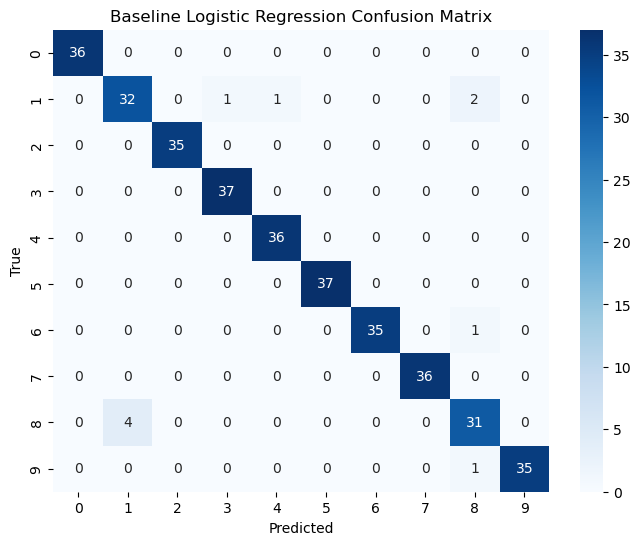

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


def fit_and_evaluate(X_train, y_train, X_test, y_test, title):
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{title} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return model

model_baseline = fit_and_evaluate(X_train_scaled, y_train, X_test_scaled, y_test, 'Baseline Logistic Regression')

# PCA visualization

Project data into 2D and compare with baseline performance.

Explained variance ratio: [0.12039695 0.09662687]


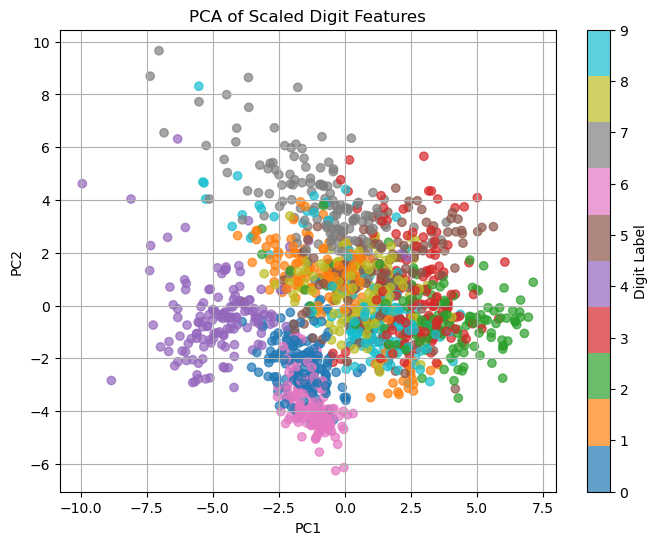

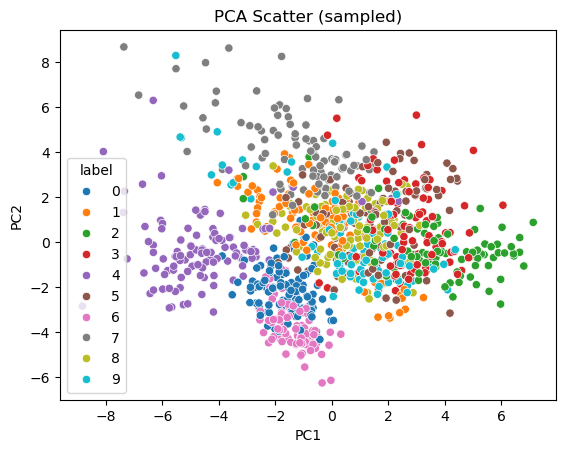

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title('PCA of Scaled Digit Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# limited pairplot for a subset of points for speed
pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_df['label'] = y_train
sns.scatterplot(data=pca_df.sample(n=1000, random_state=RANDOM_SEED), x='PC1', y='PC2', hue='label', palette='tab10', legend='brief')
plt.title('PCA Scatter (sampled)')
plt.show()

# PCA-based model evaluation

Train logistic regression on 2D PCA features and compare metrics.

=== PCA Logistic Regression ===
              precision    recall  f1-score   support

           0       0.65      0.42      0.51        36
           1       0.33      0.47      0.39        36
           2       0.55      0.83      0.66        35
           3       0.60      0.49      0.54        37
           4       0.79      0.94      0.86        36
           5       0.34      0.30      0.32        37
           6       0.64      0.81      0.72        36
           7       0.74      0.64      0.69        36
           8       0.27      0.09      0.13        35
           9       0.24      0.28      0.26        36

    accuracy                           0.53       360
   macro avg       0.52      0.53      0.51       360
weighted avg       0.52      0.53      0.51       360



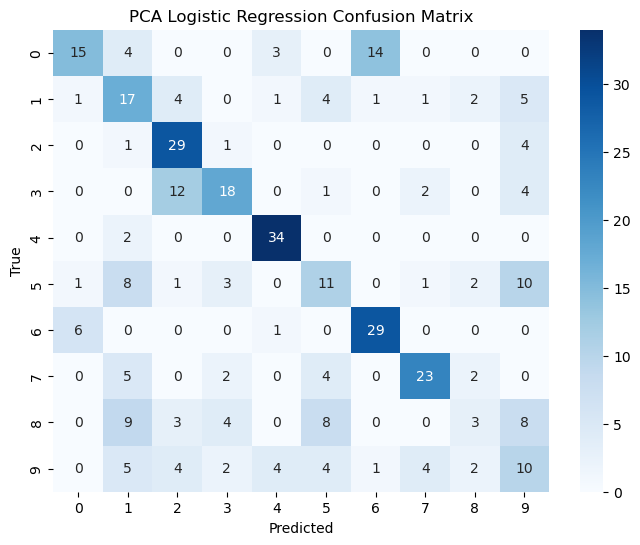

Baseline coefficients nonzero: 610
PCA coefficients nonzero: 20


In [8]:
model_pca = fit_and_evaluate(X_train_pca, y_train, X_test_pca, y_test, 'PCA Logistic Regression')

print('Baseline coefficients nonzero:', np.count_nonzero(model_baseline.coef_))
print('PCA coefficients nonzero:', np.count_nonzero(model_pca.coef_))